In [1]:
import torch
from generate_utils import load_GraphModel, load_BiLSTMModel, load_TokenBiLSTMModel
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, get_token_bilstm_embeddings_from_string_with_model, make_graph_ready_for_token_ids
import numpy as np
import matplotlib.pyplot as plt
import os

/home/maximos/miniconda3/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [3]:
device_name = 'cuda:2'
device = torch.device(device_name)

In [4]:
graph_model_path = f'saved_models/LoRA/graph/graph_model_contra_jnhw.pt'
graph_model = load_GraphModel(graph_model_path, device)
graph_model.eval()

bilstm_model_path = 'saved_models/LoRA/bilstm/bilstm_model_contra_jnhw.pt'
bilstm_model = load_BiLSTMModel(bilstm_model_path, device)
bilstm_model.eval()

token_bilstm_model_path = 'saved_models/LoRA/token_bilstm/bilstm_model_contra_jnhw.pt'
token_bilstm_model = load_TokenBiLSTMModel(token_bilstm_model_path, tokenizer, device)
token_bilstm_model.eval()

TokenHarmonyBiLSTM(
  (embedding): Embedding(355, 256, padding_idx=0)
  (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attn): Linear(in_features=512, out_features=1, bias=True)
  (output_proj): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
  )
)

In [5]:
in_seq = 'b_C#:hdim7_@4b_D:hdim7_@4'

In [6]:
y_graph = get_graph_embeddings_from_string_with_model(in_seq, graph_model)
y_bilstm = get_bilstm_embeddings_from_string_with_model(in_seq, bilstm_model)
y_token_bilstm = get_token_bilstm_embeddings_from_string_with_model(in_seq, token_bilstm_model)

In [7]:
# tokenize file
files_root = 'midi_tests'
file_names = os.listdir(files_root)

file_path = os.path.join(files_root, file_names[0])
print(file_path)

tokenized = tokenizer.encode(file_path)

midi_tests/gen_Autumn_Leaves_token_bilstm.mid


In [8]:
harmony_ids = tokenized['harmony_ids']
print(tokenized['harmony_ids'])
m = make_graph_ready_for_token_ids(harmony_ids, tokenizer)

[6, 269, 269, 269, 269, 6, 78, 78, 78, 78, 6, 78, 78, 216, 216, 6, 7, 7, 7, 7, 6, 78, 78, 78, 78, 6, 78, 78, 78, 78, 6, 129, 129, 129, 129, 6, 269, 269, 269, 269, 6, 269, 269, 269, 269, 6, 339, 339, 339, 339, 6, 66, 66, 66, 66, 6, 269, 269, 269, 269, 6, 269, 269, 269, 269, 6, 269, 269, 194, 194, 6, 78, 78, 78, 269, 6, 269, 269, 129, 129]


In [9]:
m.make_token_seq_of_segment(0,2)
print(m.segment_tokens)

tensor([269,  78])


In [14]:
m.make_token_seq_of_segment(1,3)
print(m.segment_tokens)

tensor([ 78,  78, 216])


In [ ]:
cos = torch.nn.CosineSimilarity()
# prepare a 16-bar zero background for similarity per bar
per_bar_similarity = {
    'graph': np.zeros(16),
    'bilstm': np.zeros(16),
    'token': np.zeros(16)
}
per_bar_normalizer = np.zeros(16)

In [12]:
num_seg_lens = 0
for seg_len, seg_step in zip([2,4,8], [1,2,4]):
    bar_start = 0
    bar_end = bar_start + seg_len
    while bar_end <= m.num_bars:
        m.make_graph_of_segment(bar_start, bar_end)
        m.make_bilstm_seq_of_segment(bar_start, bar_end)
        m.make_token_seq_of_segment(bar_start, bar_end)
        # graph
        seg_y_graph = graph_model(m.segment_graph)
        graph_sim = cos(y_graph, seg_y_graph).item()
        per_bar_similarity['graph'][bar_start:bar_end] += graph_sim
        # bilstm
        seg_y_bilstm = bilstm_model(m.segment_bilstm.unsqueeze(0).to(device), torch.tensor([m.segment_bilstm.shape[0]]).to(device))
        bilstm_sim = cos(y_bilstm, seg_y_bilstm).item()
        per_bar_similarity['bilstm'][bar_start:bar_end] += bilstm_sim
        # token
        seg_y_token = token_bilstm_model(m.segment_tokens.unsqueeze(0).to(device), torch.tensor([m.segment_tokens.shape[0]]).to(device))
        tokens_sim = cos(y_token_bilstm, seg_y_token).item()
        per_bar_similarity['token'][bar_start:bar_end] += tokens_sim
        print(f'bar_start: {bar_start:02} - bar_end: {bar_end:02} - g: {graph_sim:.4f} | b: {bilstm_sim:.4f} | t: {tokens_sim:.4f}')
        bar_start += seg_step
        bar_end = bar_start + seg_len
        num_seg_lens += 1

bar_start: 00 - bar_end: 02 - g: 0.7222 | b: 0.7223 | t: 0.6599
bar_start: 01 - bar_end: 03 - g: 0.1530 | b: 0.7111 | t: 0.6828
bar_start: 02 - bar_end: 04 - g: 0.1862 | b: 0.5199 | t: 0.6651
bar_start: 03 - bar_end: 05 - g: 0.7184 | b: 0.7250 | t: 0.7376
bar_start: 04 - bar_end: 06 - g: 0.6904 | b: 0.8029 | t: 0.7338
bar_start: 05 - bar_end: 07 - g: 0.5060 | b: 0.7507 | t: 0.7203
bar_start: 06 - bar_end: 08 - g: -0.0581 | b: 0.4660 | t: 0.2816
bar_start: 07 - bar_end: 09 - g: 0.0049 | b: 0.3527 | t: 0.1698
bar_start: 08 - bar_end: 10 - g: 0.6072 | b: 0.4600 | t: 0.4087
bar_start: 09 - bar_end: 11 - g: 0.3684 | b: 0.5411 | t: 0.4734


bar_start: 10 - bar_end: 12 - g: -0.2080 | b: 0.3714 | t: 0.2731
bar_start: 11 - bar_end: 13 - g: 0.0049 | b: 0.3527 | t: 0.1698
bar_start: 12 - bar_end: 14 - g: -0.2167 | b: 0.1998 | t: 0.2659
bar_start: 13 - bar_end: 15 - g: 0.0184 | b: 0.3490 | t: 0.5060
bar_start: 14 - bar_end: 16 - g: -0.1998 | b: 0.4805 | t: 0.5108
bar_start: 00 - bar_end: 04 - g: 0.2873 | b: 0.4052 | t: 0.4520
bar_start: 02 - bar_end: 06 - g: 0.0521 | b: 0.4436 | t: 0.6309
bar_start: 04 - bar_end: 08 - g: 0.1082 | b: 0.4349 | t: 0.5105
bar_start: 06 - bar_end: 10 - g: -0.1308 | b: 0.2863 | t: 0.3772
bar_start: 08 - bar_end: 12 - g: 0.0270 | b: 0.1747 | t: 0.2969
bar_start: 10 - bar_end: 14 - g: -0.2302 | b: 0.0755 | t: 0.3716
bar_start: 12 - bar_end: 16 - g: 0.1784 | b: 0.1477 | t: 0.3725
bar_start: 00 - bar_end: 08 - g: 0.2417 | b: 0.2607 | t: 0.4014
bar_start: 04 - bar_end: 12 - g: 0.0371 | b: 0.1829 | t: 0.4454
bar_start: 08 - bar_end: 16 - g: 0.2075 | b: 0.0353 | t: 0.4506


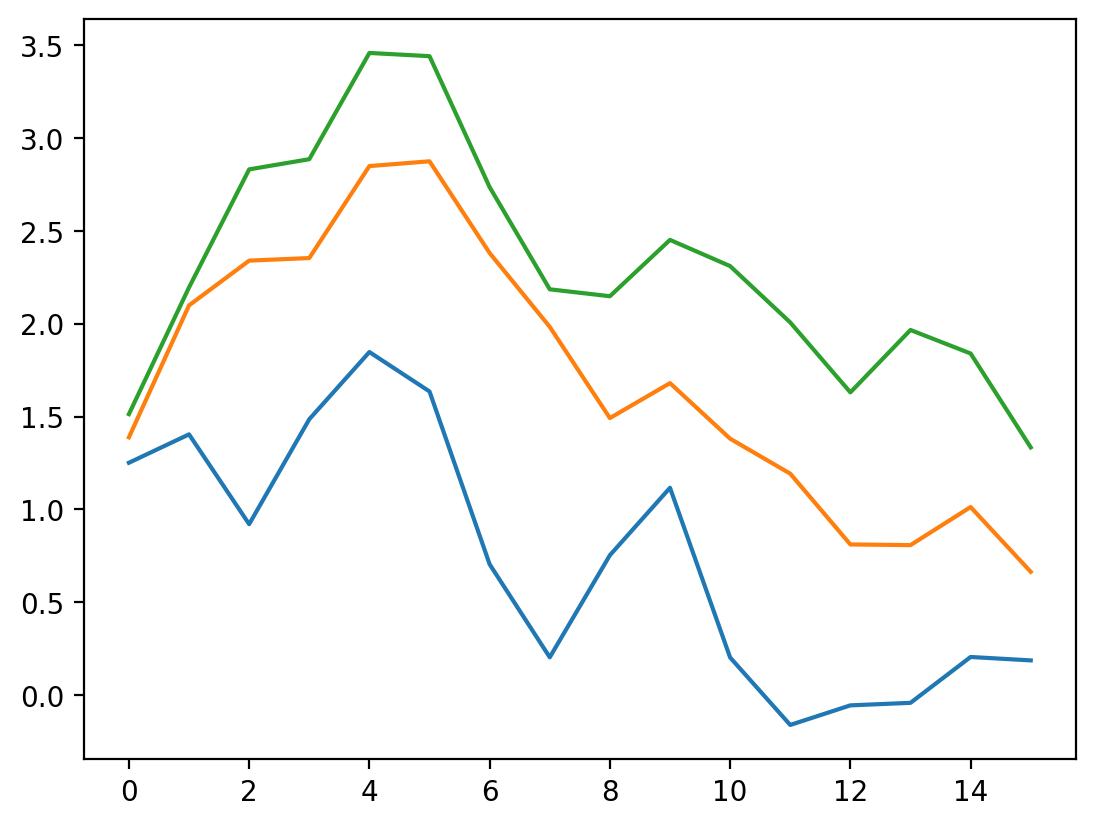

In [13]:
plt.plot(per_bar_similarity['graph'])
plt.plot(per_bar_similarity['bilstm'])
plt.plot(per_bar_similarity['token'])